In [22]:
import pandas as pd
from pprint import pprint
from bs4 import BeautifulSoup
import io

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns',None) #display all columns
pd.set_option('display.max_rows',None) #display all rows

groups_pts_src_map = {'group_1': 'cricketxi', 'group_2': 'iplt20'}
groups_team_wins_pts_map = {'group_1': 100, 'group_2': 50}
groups_team_nr_pts_map = {'group_1': 50, 'group_2': 25}
# Required Input files
# When running for the very first time, `ipl2025_results.csv`` file is required with all the team managers and an initial row of 0s.
# IPL2025MockAuctionSummary.csv file is required with each of the managers, their teams and their players listed.

# Dependencies to install
#  pip3 install beautifulsoup4
#  pip3 install lxml ??? (Double check if required)
#  pip3 install html5lib ??? (Double check if required)
#  pip3 install pywhatkit
#  pip3 install matplotlib
#  pip3 install selenium
#  pip3 install tabulate

In [ ]:
import sys
from datetime import date

# Backup the input and output files for each day for posterity

# Change for each day
ipl_day_0 = date(2026, 3, 27)
ipl_day_cur = date.today()
day_num = abs((ipl_day_cur - ipl_day_0).days)
day = 'day_' + str(day_num)
prev_day = 'day_' + str(day_num - 1)
print(day_num)

# Change for each group
group = sys.argv[1]
group_pts_source = groups_pts_src_map[group]
group_team_win_pts = groups_team_wins_pts_map[group]
group_team_nr_pts = groups_team_nr_pts_map[group]
print(group)
print(group_pts_source)
tournament = 'ipl_2026'
results_file = f'./{group}/{tournament}_results_{day}.csv'
prev_results_file = f'./{group}/{tournament}_results_{prev_day}.csv'
leaderboard_graph_file = f'./{group}/{tournament}_leaderboard.png'
leaderboard_file = f'./{group}/{tournament}_leaderboard.txt'

ipl_mock_auction_summary = f'./{group}/AuctionSummary.csv'

2
group_2
iplt20


In [24]:
mvp_df = pd.read_csv(f'./data/{group_pts_source}/mvp_{day}.csv')
mvp_df

,Player,Pts
0,devdutt padikkal,42.0
1,ryan rickelton,41.0
2,ishan kishan,40.5
3,rohit sharma,39.0
4,jacob duffy,37.0
5,virat kohli,35.5
6,shardul thakur,31.0
7,romario shepherd,29.0
8,ajinkya rahane,28.0
9,angkrish raghuvanshi,25.0


In [25]:
fantasy_teams_auction_df = pd.read_csv(ipl_mock_auction_summary)
fantasy_teams_auction_df

,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
0,Gujarat Titans,Rajasthan Royals,Royal Challengers Bengaluru,Chennai Super Kings,Sunrisers Hyderabad,Kolkata Knight Riders,Delhi Capitals,Punjab Kings,Mumbai Indians
1,Shubman Gill,Yashasvi Jaiswal,Virat Kohli,Sanju Samson,Travis Head,Sunil Narine,KL Rahul,N Tilak Varma,Rohit Sharma
2,Luhan Dre Pretorious,Shimron Hetmyer,Rajat Patidar,Ruturaj Gaikwad,Abhishek Sharma,Varun Chakravarthy,Axar Patel,Shreyas Iyer,Suryakumar Yadav
3,Anshul Kamboj,Ravindra Jadeja,Jacob Bethell,Dewald Brevis,Ishan Kishan,Mukesh Kumar,Tristan Stubbs,Marco Jansen,Quinton De Kock
4,Noor Ahmad,Mohammad Siraj,Sai Sudarshan,Vijaykumar Vyshak,Prabsimran Singh,Dhruv Jurel,Digvesh Rathi,Yuzvendra Chahal,Mitchell Santner
5,Mohammed Shami,Khaleel Ahmed,Mitchell Starc,Jacob Duffy,Romario Shepherd,Rahul Tewatia,Trent Boult,Aniket Verma,Ryan Rickleton
6,Rashid Khan,Vaibhav Arora,Shivam Dube,Suyash Sharma,Tushar Deshpande,Matt Henry,Glenn Philipps,Jasprit Bumrah,Akash Singh
7,Finn Allen,M S Dhoni,Kartik Tyagi,Rishabh Pant,Kagiso Rabada,Mayank Yadav,Aiden Markram,Ravi Bishnoi,Ashutosh Sharma
8,Naman Dhir,Jamie Overton,Nicholas Pooran,T Natarajan,V Iyer,Shahrukh Khan,Kuldeep Yadav,Priyansh Arya,Mitchell Marsh
9,Prasidh Krishna,Pathum Nissanka,Arshad Khan,Arshdeep Singh,Mayank Markande,Cameron Green,Vipraj Nigam,Prithvi Shaw,Ayush Mhatre


In [26]:
fantasy_mgrs = fantasy_teams_auction_df.columns
fantasy_mgrs.to_list()

['Kumar & Akash',
 'Vasan',
 'Manav & Sri',
 'Vasanth',
 'Raghav',
 'Arvindh',
 'Niranjani',
 'Mira & Arjun',
 'Sriram V']

In [27]:
#Make new dataframe for manager_teams 
fantasy_mgr_teams = fantasy_teams_auction_df.iloc[:1]
fantasy_mgr_teams

,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
0,Gujarat Titans,Rajasthan Royals,Royal Challengers Bengaluru,Chennai Super Kings,Sunrisers Hyderabad,Kolkata Knight Riders,Delhi Capitals,Punjab Kings,Mumbai Indians


In [28]:
import os
#Create new dataframe for manager_players
fantasy_teams_df = fantasy_teams_auction_df.iloc[1:]
fantasy_teams_df = fantasy_teams_df.apply(lambda x: x.astype(str).str.lower())

fantasy_teams_df_per_mgr = {}
for mgr in fantasy_teams_df.columns:
    mgr_file = f'./{group}/{mgr}.csv'
    if not os.path.exists(mgr_file):
        df = pd.DataFrame(fantasy_teams_df[mgr])
        df.to_csv(mgr_file, index=False)
    else:
        df = pd.read_csv(mgr_file)
    fantasy_teams_df_per_mgr[mgr] = df
fantasy_teams_df


,Kumar & Akash,Vasan,Manav & Sri,Vasanth,Raghav,Arvindh,Niranjani,Mira & Arjun,Sriram V
1,shubman gill,yashasvi jaiswal,virat kohli,sanju samson,travis head,sunil narine,kl rahul,n tilak varma,rohit sharma
2,luhan dre pretorious,shimron hetmyer,rajat patidar,ruturaj gaikwad,abhishek sharma,varun chakravarthy,axar patel,shreyas iyer,suryakumar yadav
3,anshul kamboj,ravindra jadeja,jacob bethell,dewald brevis,ishan kishan,mukesh kumar,tristan stubbs,marco jansen,quinton de kock
4,noor ahmad,mohammad siraj,sai sudarshan,vijaykumar vyshak,prabsimran singh,dhruv jurel,digvesh rathi,yuzvendra chahal,mitchell santner
5,mohammed shami,khaleel ahmed,mitchell starc,jacob duffy,romario shepherd,rahul tewatia,trent boult,aniket verma,ryan rickleton
6,rashid khan,vaibhav arora,shivam dube,suyash sharma,tushar deshpande,matt henry,glenn philipps,jasprit bumrah,akash singh
7,finn allen,m s dhoni,kartik tyagi,rishabh pant,kagiso rabada,mayank yadav,aiden markram,ravi bishnoi,ashutosh sharma
8,naman dhir,jamie overton,nicholas pooran,t natarajan,v iyer,shahrukh khan,kuldeep yadav,priyansh arya,mitchell marsh
9,prasidh krishna,pathum nissanka,arshad khan,arshdeep singh,mayank markande,cameron green,vipraj nigam,prithvi shaw,ayush mhatre
10,hardik pandya,liam livingstone,pat cummins,avesh khan,salil arora,phil salt,krunal pandya,harsh dubey,nitish rana


In [29]:
from thefuzz import fuzz
from thefuzz import process
            
# Compute total score for each fantasy team based on MVP points of each player
scores = { fantasy_mgr:0 for fantasy_mgr in fantasy_mgrs.to_list() }
for mgr in fantasy_mgrs:
    print(mgr)
    mgr_df = fantasy_teams_df_per_mgr[mgr]
    mgr_day_pts = {}
    mgr_file = f'./{group}/{mgr}.csv'
    all_players_have_min_pts = True
    mvp_players_with_pts = mvp_df['Player'].to_list()
    for i in range(len(fantasy_teams_df[mgr])):
        player_name = str(fantasy_teams_df[mgr].iloc[i]).lower()
        if player_name in mvp_players_with_pts:
            player_score = float(mvp_df.loc[mvp_df['Player'] == fantasy_teams_df[mgr].iloc[i],'Pts'].iloc[0])
            scores[mgr] += player_score
            mgr_day_pts[player_name] = player_score
            print(f'\t{player_name} points found. Adding his score {player_score} to total. New score {scores[mgr]}')
        else:
            closest_match = process.extractOne(player_name, mvp_players_with_pts)
            mgr_day_pts[player_name] = 0.0
            print(f'\t{player_name} not found in mvp_table... Double check the spelling of player name, closest match is {closest_match}')
            all_players_have_min_pts = False
    mgr_df[f'{day}'] = mgr_df.iloc[:, 0].map(mgr_day_pts)
    mgr_df = mgr_df.reindex(sorted(mgr_df.columns, key = lambda x: int(x.split("_")[1] if '_' in x else 0)), axis=1)
    mgr_df.to_csv(mgr_file, index=False)
    print(f'*{day.upper()}*\n```\n{mgr_df.to_markdown(index=False)}\n```')
    if all_players_have_min_pts:
        print(f'All players have min fantasy points.')

Kumar & Akash
	shubman gill not found in mvp_table... Double check the spelling of player name, closest match is ('ishan kishan', 50)
	luhan dre pretorious not found in mvp_table... Double check the spelling of player name, closest match is ('naman dhir', 50)
	anshul kamboj not found in mvp_table... Double check the spelling of player name, closest match is ('anukul roy', 52)
	noor ahmad not found in mvp_table... Double check the spelling of player name, closest match is ('naman dhir', 50)
	mohammed shami not found in mvp_table... Double check the spelling of player name, closest match is ('rohit sharma', 54)
	rashid khan not found in mvp_table... Double check the spelling of player name, closest match is ('ishan kishan', 61)
	finn allen points found. Adding his score 22.0 to total. New score 22.0
	naman dhir points found. Adding his score 2.5 to total. New score 24.5
	prasidh krishna not found in mvp_table... Double check the spelling of player name, closest match is ('ishan kishan', 

In [30]:
scores

{'Kumar & Akash': 48.5,
 'Vasan': 57.0,
 'Manav & Sri': 67.0,
 'Vasanth': 88.5,
 'Raghav': 93.0,
 'Arvindh': 77.0,
 'Niranjani': 33.0,
 'Mira & Arjun': 56.5,
 'Sriram V': 45.0}

In [31]:
ipl_team_pts_tbl = pd.read_csv(f'./data/standings_{day}.csv')
ipl_team_pts_tbl

,Teams,M,W,L,T,N/R,PTS,NRR,Series Form,Next,For,Against
0,Royal Challengers Bengaluru,1,1,0,0,0,2,2.907,W,"vs CSK, RR, MI",203/15.4,201/20.0
1,Mumbai Indians,1,1,0,0,0,2,0.687,W,"vs DC, RR, RCB",224/19.1,220/20.0
2,Kolkata Knight Riders,1,0,1,0,0,0,-0.687,L,"vs SRH, PBKS, LSG",220/20.0,224/19.1
3,Sunrisers Hyderabad,1,0,1,0,0,0,-2.907,L,"vs KKR, LSG, PBKS",201/20.0,203/15.4
4,Chennai Super Kings,-,-,-,-,-,-,-,NaN,"vs RR, PBKS, RCB",-,-
5,Delhi Capitals,-,-,-,-,-,-,-,NaN,"vs LSG, MI, GT",-,-
6,Gujarat Titans,-,-,-,-,-,-,-,NaN,"vs PBKS, RR, DC",-,-
7,Lucknow Super Giants,-,-,-,-,-,-,-,NaN,"vs DC, SRH, KKR",-,-
8,Punjab Kings,-,-,-,-,-,-,-,NaN,"vs GT, CSK, KKR",-,-
9,Rajasthan Royals,-,-,-,-,-,-,-,NaN,"vs CSK, GT, MI",-,-


In [32]:
for mgr in fantasy_teams_df.columns:
    no_of_wins = 0
    no_of_nrs = 0
    if fantasy_mgr_teams[mgr].item() in ipl_team_pts_tbl.Teams.to_list():
        no_of_wins = ipl_team_pts_tbl.loc[ipl_team_pts_tbl['Teams'] == fantasy_mgr_teams[mgr].item(),'W'].item()
        if no_of_wins == '-':
            no_of_wins=0
        no_of_nrs = ipl_team_pts_tbl.loc[ipl_team_pts_tbl['Teams'] == fantasy_mgr_teams[mgr].item(),'N/R'].item()
        if no_of_nrs == '-':
            no_of_nrs=0
        scores[mgr] += (float(no_of_wins)*group_team_win_pts)
        scores[mgr] += (float(no_of_nrs)*group_team_nr_pts)
        print(f'{str(mgr)}\t{str(fantasy_mgr_teams[mgr].values)}\twins:{str(no_of_wins)}\tnr:{str(no_of_nrs)}')
scores

Kumar & Akash	['Gujarat Titans']	wins:0	nr:0
Vasan	['Rajasthan Royals']	wins:0	nr:0
Manav & Sri	['Royal Challengers Bengaluru']	wins:1	nr:0
Vasanth	['Chennai Super Kings']	wins:0	nr:0
Raghav	['Sunrisers Hyderabad']	wins:0	nr:0
Arvindh	['Kolkata Knight Riders']	wins:0	nr:0
Niranjani	['Delhi Capitals']	wins:0	nr:0
Mira & Arjun	['Punjab Kings']	wins:0	nr:0
Sriram V	['Mumbai Indians']	wins:1	nr:0


{'Kumar & Akash': 48.5,
 'Vasan': 57.0,
 'Manav & Sri': 117.0,
 'Vasanth': 88.5,
 'Raghav': 93.0,
 'Arvindh': 77.0,
 'Niranjani': 33.0,
 'Mira & Arjun': 56.5,
 'Sriram V': 95.0}

In [33]:
prev_scores = pd.read_csv(prev_results_file, header=None)
prev_scores = prev_scores.T
new_header = prev_scores.iloc[0]
prev_scores = prev_scores[1:]
prev_scores.columns = new_header
prev_scores_dicts = prev_scores.to_dict(orient='records')
prev_scores_dicts

[{'Manav & Sri': 0.0,
  'Raghav': 0.0,
  'Vasanth': 0.0,
  'Vasan': 0.0,
  'Mira & Arjun': 0.0,
  'Niranjani': 0.0,
  'Arvindh': 0.0,
  'Kumar & Akash': 0.0,
  'Sriram V': 0.0},
 {'Manav & Sri': 98.0,
  'Raghav': 65.0,
  'Vasanth': 46.5,
  'Vasan': 39.0,
  'Mira & Arjun': 34.0,
  'Niranjani': 22.5,
  'Arvindh': 17.5,
  'Kumar & Akash': 0.0,
  'Sriram V': 0.0}]

In [34]:
current_scores_dict = prev_scores_dicts + [scores]

In [35]:
graph_scores = pd.DataFrame(current_scores_dict)
graph_scores

,Manav & Sri,Raghav,Vasanth,Vasan,Mira & Arjun,Niranjani,Arvindh,Kumar & Akash,Sriram V
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,98.0,65.0,46.5,39.0,34.0,22.5,17.5,0.0,0.0
2,117.0,93.0,88.5,57.0,56.5,33.0,77.0,48.5,95.0


In [36]:
graph_scores_t = graph_scores.T
graph_scores_t = graph_scores_t.sort_values(by=graph_scores_t.columns[-1], ascending=False)
graph_scores_t.to_csv(results_file, header=False)
graph_scores_t

,0,1,2
Manav & Sri,0.0,98.0,117.0
Sriram V,0.0,0.0,95.0
Raghav,0.0,65.0,93.0
Vasanth,0.0,46.5,88.5
Arvindh,0.0,17.5,77.0
Vasan,0.0,39.0,57.0
Mira & Arjun,0.0,34.0,56.5
Kumar & Akash,0.0,0.0,48.5
Niranjani,0.0,22.5,33.0


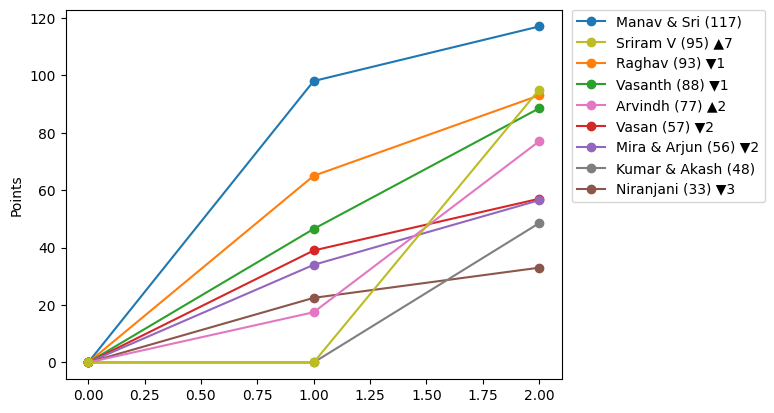

In [37]:
import matplotlib.pyplot as plt
ax = graph_scores.plot.line(marker='o')
#ax.set_xlabel("Days")
ax.set_ylabel("Points")
# Create legend labels with final scores, sorted by points (descending)
final_scores = graph_scores.iloc[-1]
sorted_cols = final_scores.sort_values(ascending=False).index

# Calculate position changes (if there are at least 2 days of data)
position_changes = {}
if len(graph_scores) >= 2:
    prev_scores = graph_scores.iloc[-2]
    prev_sorted = prev_scores.sort_values(ascending=False).index
    
    # Create position mappings
    prev_positions = {col: idx for idx, col in enumerate(prev_sorted)}
    curr_positions = {col: idx for idx, col in enumerate(sorted_cols)}
    
    # Calculate changes (negative means moved up, positive means moved down)
    for col in sorted_cols:
        if col in prev_positions:
            position_changes[col] = prev_positions[col] - curr_positions[col]
        else:
            position_changes[col] = 0
else:
    # No previous data, all changes are 0
    for col in sorted_cols:
        position_changes[col] = 0

# Get handles and labels from the plot
handles, labels = ax.get_legend_handles_labels()
# Create a mapping of original column names to handles
handle_dict = dict(zip(graph_scores.columns, handles))
# Reorder handles and create new labels based on sorted columns with position change indicators
sorted_handles = [handle_dict[col] for col in sorted_cols]
sorted_labels = []
for col in sorted_cols:
    change = position_changes[col]
    if change > 0:
        # Upward triangle for improvement (will be colored green)
        indicator = f" ▲{change}"
    elif change < 0:
        # Downward triangle for decline (will be colored red)
        indicator = f" ▼{abs(change)}"
    else:
        indicator = ""
    sorted_labels.append(f"{col} ({int(final_scores[col])}){indicator}")

legend = plt.legend(sorted_handles, sorted_labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.savefig(leaderboard_graph_file, bbox_inches="tight")
plt.show()

In [38]:
scores_sorted = {k: v for k, v in sorted(scores.items(), key=lambda item: item[1], reverse=True)}
score_msg = str(scores_sorted)

scores_msg_df = pd.DataFrame(
    scores_sorted.items(),
    columns=['Manager', 'Points']
)
leaderboard_table = f'*{day.upper()}*\n```\n{scores_msg_df.to_markdown(index=False)}\n```'
print()
with open(leaderboard_file, 'w') as f:
    f.write(leaderboard_table)